# Methods and Samplers in GenSBI

GenSBI supports three generative methods for simulation-based inference:

1. **Flow Matching** — learns a velocity field and integrates an ODE from noise to data.
2. **EDM Diffusion** — learns a denoiser in σ-space (Karras et al., 2022).
3. **Score Matching** — learns the score function ∇ log p_t(x) (Song et al., 2021).

Each method has a default solver and one or more alternatives that can be swapped
at **sample time** without retraining. This example trains one model per method and
demonstrates all available sampling strategies.

We use the unified `ConditionalPipeline` API throughout, which is model-agnostic
and parameterized by a `GenerativeMethod` object.

In [1]:
# automatically install dependencies if using Colab
try: #check if we are using colab, if so install all the required software
    import google.colab
    colab=True
except:
    colab=False

if colab: # you may have to restart the runtime after installing the packages
    !uv pip install --quiet "gensbi[cuda12, examples] @ git+https://github.com/aurelio-amerio/GenSBI"
    !git clone --depth 1 https://github.com/aurelio-amerio/GenSBI-examples
    %cd GenSBI-examples/examples/methods_and_samplers

In [2]:
import os

# Set JAX backend (use 'cuda' for GPU, 'cpu' otherwise)
os.environ["JAX_PLATFORMS"] = "cuda"

import grain
import numpy as np
import jax
from jax import numpy as jnp
from numpyro import distributions as dist
from flax import nnx

# Unified pipeline and generative methods
from gensbi.recipes import ConditionalPipeline
from gensbi.core import FlowMatchingMethod, DiffusionEDMMethod, ScoreMatchingMethod

# Model
from gensbi.models import Flux1, Flux1Params

# Plotting
from gensbi.utils.plotting import plot_marginals
import matplotlib.pyplot as plt

/home/aure/github/GenSBI/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Shared Setup

We use a simple 3D toy problem throughout: the simulator draws parameters θ from a
uniform prior and produces observations x = θ + 1 + noise. This is identical to the
`conditional_pipeline.py` example, so we can focus on the methods and samplers.

In [3]:
theta_prior = dist.Uniform(
    low=jnp.array([-2.0, -2.0, -2.0]), high=jnp.array([2.0, 2.0, 2.0])
)

dim_obs = 3
dim_cond = 3
dim_joint = dim_obs + dim_cond


def simulator(key, nsamples):
    theta_key, sample_key = jax.random.split(key, 2)
    thetas = theta_prior.sample(theta_key, (nsamples,))
    xs = thetas + 1 + jax.random.normal(sample_key, thetas.shape) * 0.1

    thetas = thetas[..., None]
    xs = xs[..., None]

    # For the conditional pipeline, thetas (observations) come first
    data = jnp.concatenate([thetas, xs], axis=1)
    return data

In [4]:
train_data = simulator(jax.random.PRNGKey(0), 100_000)
val_data = simulator(jax.random.PRNGKey(1), 2000)

In [5]:
# Normalizing the data to zero mean and unit variance is important for stable training.
means = jnp.mean(train_data, axis=0)
stds = jnp.std(train_data, axis=0)


def normalize(data, means, stds):
    return (data - means) / stds


def unnormalize(data, means, stds):
    return data * stds + means

In [6]:
# The conditional pipeline expects each batch to be a tuple of (observations, conditions).
def split_obs_cond(data):
    data = normalize(data, means, stds)
    return (
        data[:, :dim_obs],
        data[:, dim_obs:],
    )

In [7]:
batch_size = 256

train_dataset_grain = (
    grain.MapDataset.source(np.array(train_data))
    .shuffle(42)
    .repeat()
    .to_iter_dataset()
    .batch(batch_size)
    .map(split_obs_cond)
)

val_dataset_grain = (
    grain.MapDataset.source(np.array(val_data))
    .shuffle(42)
    .repeat()
    .to_iter_dataset()
    .batch(batch_size)
    .map(split_obs_cond)
)

In [8]:
# We generate one observation from the simulator and extract the true parameters
# and the conditioning data x_o. This will be reused across all methods.
new_sample = simulator(jax.random.PRNGKey(20), 1)
true_theta = new_sample[:, :dim_obs, :]

new_sample_norm = normalize(new_sample, means, stds)
x_o = new_sample_norm[:, dim_obs:, :]

# Plotting range (same for all methods)
plot_range = [(1, 3), (1, 3), (-0.6, 0.5)]

## Model parameters

In [9]:
params = Flux1Params(
    in_channels=1,
    vec_in_dim=None,
    context_in_dim=1,
    mlp_ratio=3,
    num_heads=4,
    depth=4,
    depth_single_blocks=8,
    val_emb_dim=10,
    id_emb_dim=4,
    qkv_bias=True,
    dim_obs=dim_obs,
    dim_cond=dim_cond,
    id_embedding_strategy=("absolute", "absolute"),
    id_merge_mode="concat",
    rngs=nnx.Rngs(default=42),
    param_dtype=jnp.float32,
)

---
## Section 1: Flow Matching

**Flow Matching** learns a velocity field $v_\theta(t, x)$ that transports samples
from a simple prior (Gaussian noise at $t=0$) to the data distribution (at $t=1$)
via an ordinary differential equation (ODE).

- **Default solver**: `FMODESolver` — deterministic ODE integration (Euler or Dopri5).
- **Alternative solvers** (SDE-based, stochastic):
  - `ZeroEndsSolver` — diffusion vanishes at both time endpoints (arXiv:2410.02217).
  - `NonSingularSolver` — non-singular diffusion coefficient (arXiv:2410.02217).

The SDE solvers can sometimes improve sample diversity at the cost of
additional stochasticity. The prior statistics (`mu0`, `sigma0`) are auto-provided;
only the diffusion strength parameter `alpha` must be specified.

In [10]:
model_fm = Flux1(params)

method_fm = FlowMatchingMethod()

training_config_fm = ConditionalPipeline.get_default_training_config()
training_config_fm["nsteps"] = 10000
training_config_fm["checkpoint_dir"] = os.path.join(os.getcwd(), "checkpoints", "flow")

pipeline_fm = ConditionalPipeline(
    model_fm,
    train_dataset_grain,
    val_dataset_grain,
    dim_obs=dim_obs,
    dim_cond=dim_cond,
    method=method_fm,
    training_config=training_config_fm,
)

In [ ]:
# Uncomment the following lines to train the model.
# Once trained, the model is saved to checkpoints/flow and can be restored below.
rngs = nnx.Rngs(42)
# pipeline_fm.train(rngs, save_model=True)

  0%|          | 0/10000 [00:00<?, ?it/s]E0315 20:07:24.684960    7958 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0315 20:07:24.787088    7950 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0315 20:07:28.135102    7958 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
100%|██████████| 10000/10000 [13:39<00:00, 12.21it/s, counter=0, loss=0.1340, ratio=1.0193, val_loss=0.1105]


Saved model to checkpoint


([Array(4.487134, dtype=float32),
  Array(2.9922855, dtype=float32),
  Array(1.960834, dtype=float32),
  Array(1.0761648, dtype=float32),
  Array(0.5249662, dtype=float32),
  Array(0.29900214, dtype=float32),
  Array(0.20662096, dtype=float32),
  Array(0.17570512, dtype=float32),
  Array(0.16001049, dtype=float32),
  Array(0.15263854, dtype=float32),
  Array(0.14871691, dtype=float32),
  Array(0.1458437, dtype=float32),
  Array(0.14513807, dtype=float32),
  Array(0.14279085, dtype=float32),
  Array(0.14386567, dtype=float32),
  Array(0.14367118, dtype=float32),
  Array(0.14287081, dtype=float32),
  Array(0.14172928, dtype=float32),
  Array(0.13863182, dtype=float32),
  Array(0.13995412, dtype=float32),
  Array(0.13849655, dtype=float32),
  Array(0.13940008, dtype=float32),
  Array(0.14105442, dtype=float32),
  Array(0.13809459, dtype=float32),
  Array(0.13874346, dtype=float32),
  Array(0.13746428, dtype=float32),
  Array(0.13833494, dtype=float32),
  Array(0.1407088, dtype=float32),
 

In [ ]:
pipeline_fm.restore_model()

In [13]:
# The default solver for flow matching is the FMODESolver, which performs deterministic
# ODE integration from noise (t=0) to data (t=1).
samples_fm = pipeline_fm.sample(rngs.sample(), x_o, nsamples=100_000)
samples_fm = unnormalize(samples_fm, means[:dim_obs], stds[:dim_obs])

E0315 20:21:02.674392    7959 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


<Figure size 640x480 with 0 Axes>

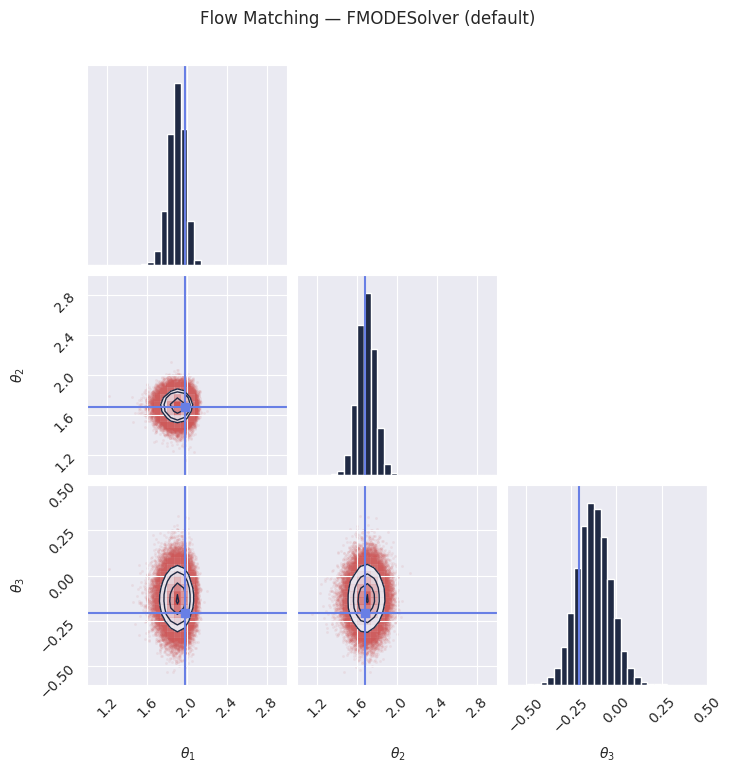

In [14]:
plot_marginals(
    np.array(samples_fm[..., 0]),
    gridsize=30,
    true_param=np.array(true_theta[0, :, 0]),
    range=plot_range,
)
plt.suptitle("Flow Matching — FMODESolver (default)", y=1.02)
plt.savefig("fm_ode_marginals.png", dpi=100, bbox_inches="tight")
plt.show()

<img src="https://raw.githubusercontent.com/aurelio-amerio/GenSBI-examples/refs/heads/main/examples/methods_and_samplers/fm_ode_marginals.png" width=800>

In [15]:
# The ZeroEndsSolver adds stochastic noise during sampling. The diffusion coefficient
# vanishes at both t=0 and t=1, ensuring clean endpoints.
# Required kwarg: alpha (diffusion strength). mu0/sigma0 are auto-provided by the prior.
from gensbi.flow_matching.solver import ZeroEndsSolver

solver_kwargs_ze = {
    "alpha": 0.2,  # diffusion strength
}

samples_fm_ze = pipeline_fm.sample(
    rngs.sample(),
    x_o,
    nsamples=100_000,
    solver=(ZeroEndsSolver, solver_kwargs_ze),
)
samples_fm_ze = unnormalize(samples_fm_ze, means[:dim_obs], stds[:dim_obs])

<Figure size 640x480 with 0 Axes>

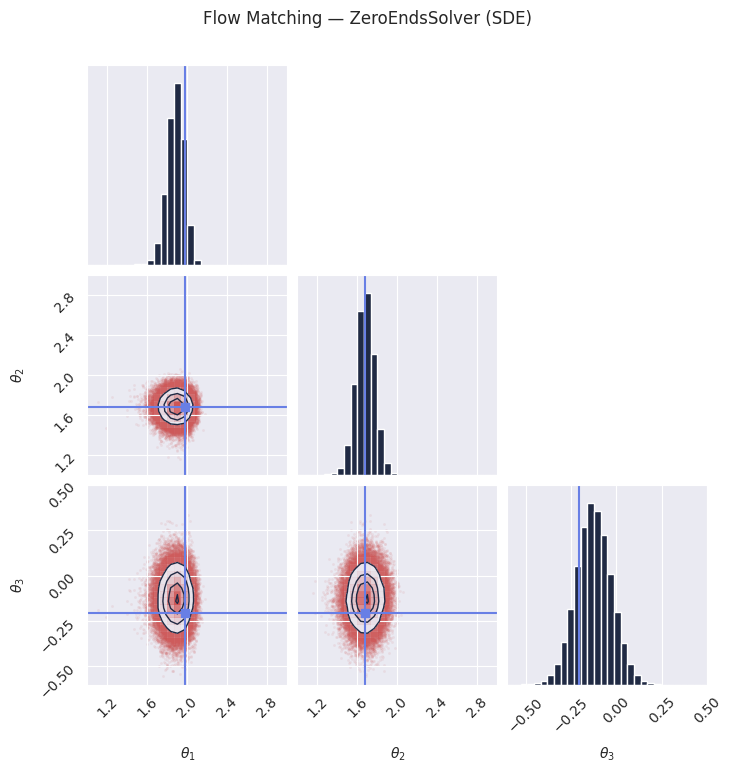

In [16]:
plot_marginals(
    np.array(samples_fm_ze[..., 0]),
    gridsize=30,
    true_param=np.array(true_theta[0, :, 0]),
    range=plot_range,
)
plt.suptitle("Flow Matching — ZeroEndsSolver (SDE)", y=1.02)
plt.savefig("fm_zeroends_marginals.png", dpi=100, bbox_inches="tight")
plt.show()

<img src="https://raw.githubusercontent.com/aurelio-amerio/GenSBI-examples/refs/heads/main/examples/methods_and_samplers/fm_zeroends_marginals.png" width=800>

In [17]:
# The NonSingularSolver uses a non-singular diffusion coefficient, which can provide
# different sample quality characteristics compared to ZeroEndsSolver.
# It takes the same kwargs as ZeroEndsSolver.
from gensbi.flow_matching.solver import NonSingularSolver

solver_kwargs_ns = {
    "alpha": 0.2,
}

samples_fm_ns = pipeline_fm.sample(
    rngs.sample(),
    x_o,
    nsamples=100_000,
    solver=(NonSingularSolver, solver_kwargs_ns),
)
samples_fm_ns = unnormalize(samples_fm_ns, means[:dim_obs], stds[:dim_obs])

<Figure size 640x480 with 0 Axes>

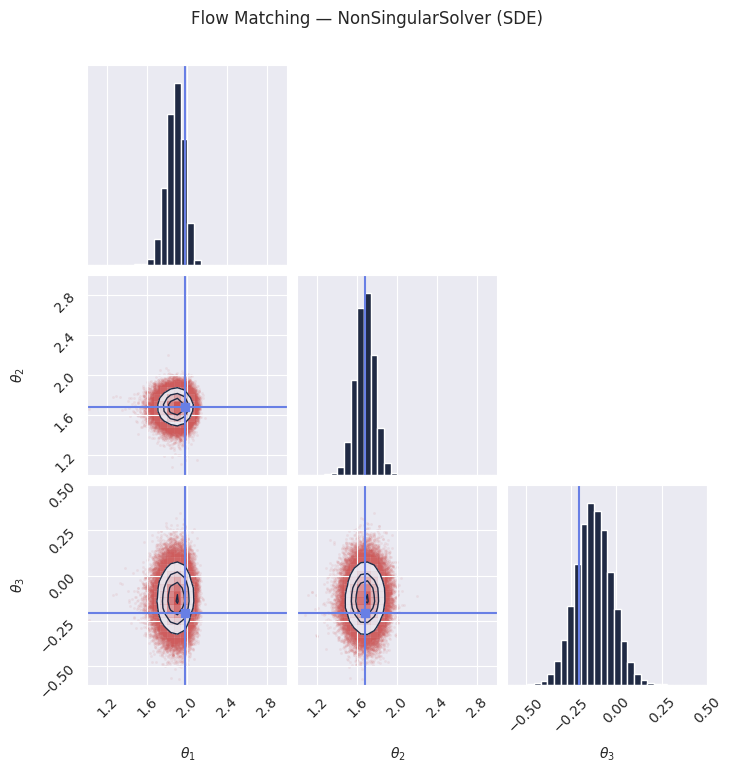

In [18]:
plot_marginals(
    np.array(samples_fm_ns[..., 0]),
    gridsize=30,
    true_param=np.array(true_theta[0, :, 0]),
    range=plot_range,
)
plt.suptitle("Flow Matching — NonSingularSolver (SDE)", y=1.02)
plt.savefig("fm_nonsingular_marginals.png", dpi=100, bbox_inches="tight")
plt.show()

<img src="https://raw.githubusercontent.com/aurelio-amerio/GenSBI-examples/refs/heads/main/examples/methods_and_samplers/fm_nonsingular_marginals.png" width=800>

### Computing the log-prob (Flow Matching)

Flow matching supports exact log-probability evaluation via the continuous
change-of-variables formula. This requires solving an ODE backward, so it is
more expensive than sampling, but it gives the exact (approximate) posterior
density at any point.

In [19]:
from gensbi.utils.plotting import _plot_2d_dist_contour

In [20]:
# Build a meshgrid in *unnormalized* space, then normalize for the pipeline.
# The plot_range we used for marginals is a good guide for the grid extent.
theta1_raw = np.linspace(1.6, 2.4, 50)
theta2_raw = np.linspace(1.4, 2.4, 51)
theta3_raw = np.linspace(-0.5, 0.3, 52)

# Normalize to the training data statistics (obs dims only)
means_obs = means[:dim_obs, :]
stds_obs = stds[:dim_obs, :]

theta1 = (theta1_raw - means_obs[0, 0].item()) / stds_obs[0, 0].item()
theta2 = (theta2_raw - means_obs[1, 0].item()) / stds_obs[1, 0].item()
theta3 = (theta3_raw - means_obs[2, 0].item()) / stds_obs[2, 0].item()

tt1, tt2, tt3 = jnp.meshgrid(theta1, theta2, theta3, indexing="ij")

x_1 = jnp.stack([tt1.ravel(), tt2.ravel(), tt3.ravel()], axis=-1)[..., None]

In [21]:
logp_fm = pipeline_fm.log_prob(x_1, x_o, use_ema=True)

E0315 20:22:24.518832    7953 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0315 20:22:24.662507    7947 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0315 20:22:25.289675    7957 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0315 20:22:25.724458    7955 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0315 20:22:25.812909    7955 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0315 20:22:26.513620    7949 cuda_timer.cc:8

In [60]:
jnp.prod(stds_obs.flatten())

Array(1.5409526, dtype=float32)

In [58]:
stds_obs

Array([[1.1551673],
       [1.1542176],
       [1.1557308]], dtype=float32)

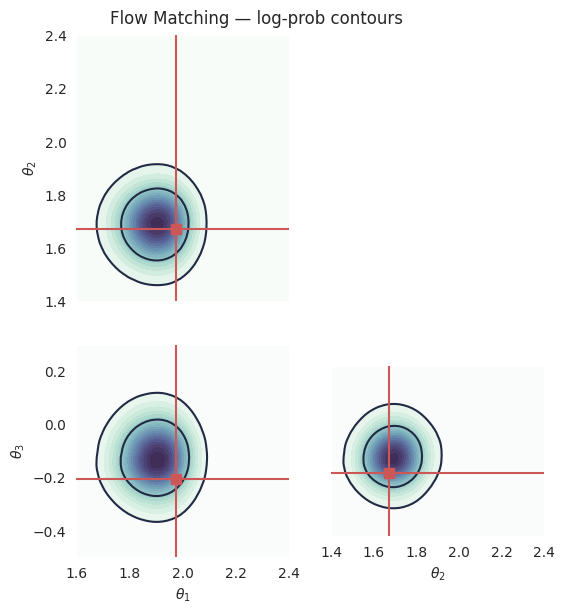

In [69]:
prob_fm = jnp.exp(logp_fm).reshape((len(theta1_raw), len(theta2_raw), len(theta3_raw)))

# since we did a change of variables, p(x_norm) = p(x)*|det(J)|, where J is the jacobian of the change of variables
# we are interested in plotting p(x)
# J = stds_obs, so we need to divide by the product of stds
prob_fm = prob_fm / jnp.prod(stds_obs.flatten())

# Integrate out one dimension to get 2D marginal distributions
prob12_fm = jnp.trapezoid(prob_fm, x=theta3, axis=2)
prob13_fm = jnp.trapezoid(prob_fm, x=theta2, axis=1)
prob23_fm = jnp.trapezoid(prob_fm, x=theta1, axis=0)

fig, axes = plt.subplots(2, 2, figsize=(6, 6))

ax = axes[1, 0]
_plot_2d_dist_contour(theta1_raw, theta3_raw, prob13_fm.T, ax=ax,
                      true_param=[true_theta[:, 0], true_theta[:, 2]])
ax.set_xlabel(r"$\theta_1$")
ax.set_ylabel(r"$\theta_3$")


ax = axes[1, 1]
_plot_2d_dist_contour(theta2_raw, theta3_raw, prob23_fm.T, ax=ax,
                      true_param=[true_theta[:, 1], true_theta[:, 2]])
ax.set_xlabel(r"$\theta_2$")
ax.set_ylabel("")
ax.set_yticks([])


ax = axes[0, 0]
_plot_2d_dist_contour(theta1_raw, theta2_raw, prob12_fm.T, ax=ax,
                      true_param=[true_theta[:, 0], true_theta[:, 1]])
ax.set_xlabel("")
ax.set_xticks([])
ax.set_ylabel(r"$\theta_2$")


axes[0, 1].set_visible(False)

fig.subplots_adjust(hspace=0.05, wspace=0.2, left=0.2, right=0.98, top=0.98, bottom=0.06)
for ax in axes.ravel():
    ax.set_aspect("equal", adjustable="box")
    # ax.set_aspect("equal")

plt.suptitle("Flow Matching — log-prob contours", y=1.02)
plt.savefig("fm_log_prob.png", dpi=300, bbox_inches="tight")
plt.show()

In [23]:
del model_fm, pipeline_fm

---
## Section 2: EDM Diffusion

**EDM Diffusion** (Karras et al., 2022) learns a denoiser $D_\theta(x; \sigma)$ in
$\sigma$-space. The training noise schedule can use one of three prescriptions:

- `DiffusionEDMMethod()` — default EDM scheduler (**recommended**)
- `DiffusionEDMMethod(sde="VP")` — Variance Preserving scheduler
- `DiffusionEDMMethod(sde="VE")` — Variance Exploding scheduler

The model can be trained with any of these three prescriptions, and then sampled
using any of the three as well. However, the **EDM scheduler is recommended** for
both training and sampling. The scheduler variants are training-time choices that
affect the noise schedule used during the diffusion process.

**Solver**: `EDMSolver` is the only available solver for EDM. It implements the
stochastic denoising sampler from Karras et al., 2022.

In [24]:
model_edm = Flux1(params)

# Default EDM scheduler (recommended for both training and sampling)
method_edm = DiffusionEDMMethod()
# Alternative training schedulers (uncomment to use):
# method_edm = DiffusionEDMMethod(sde="VP")  # Variance Preserving
# method_edm = DiffusionEDMMethod(sde="VE")  # Variance Exploding

training_config_edm = ConditionalPipeline.get_default_training_config()
training_config_edm["nsteps"] = 10000
training_config_edm["checkpoint_dir"] = os.path.join(os.getcwd(), "checkpoints", "edm")

pipeline_edm = ConditionalPipeline(
    model_edm,
    train_dataset_grain,
    val_dataset_grain,
    dim_obs=dim_obs,
    dim_cond=dim_cond,
    method=method_edm,
    training_config=training_config_edm,
)

In [ ]:
# Uncomment the following lines to train the model.
# Once trained, the model is saved to checkpoints/edm and can be restored below.
rngs = nnx.Rngs(42)
# pipeline_edm.train(rngs, save_model=True)

100%|██████████| 10000/10000 [15:01<00:00, 11.10it/s, counter=0, loss=0.6074, ratio=1.0059, val_loss=0.4663]


Saved model to checkpoint


([Array(4.059249, dtype=float32),
  Array(3.217333, dtype=float32),
  Array(2.613893, dtype=float32),
  Array(1.8376857, dtype=float32),
  Array(1.1931707, dtype=float32),
  Array(0.8978646, dtype=float32),
  Array(0.7617746, dtype=float32),
  Array(0.70925975, dtype=float32),
  Array(0.68048674, dtype=float32),
  Array(0.663169, dtype=float32),
  Array(0.6580681, dtype=float32),
  Array(0.6520192, dtype=float32),
  Array(0.6546059, dtype=float32),
  Array(0.65086615, dtype=float32),
  Array(0.6381018, dtype=float32),
  Array(0.6430618, dtype=float32),
  Array(0.6428918, dtype=float32),
  Array(0.6356992, dtype=float32),
  Array(0.6338464, dtype=float32),
  Array(0.63547117, dtype=float32),
  Array(0.625504, dtype=float32),
  Array(0.62820774, dtype=float32),
  Array(0.6310612, dtype=float32),
  Array(0.6290156, dtype=float32),
  Array(0.62686634, dtype=float32),
  Array(0.6252855, dtype=float32),
  Array(0.61055213, dtype=float32),
  Array(0.6176732, dtype=float32),
  Array(0.61402166

In [ ]:
pipeline_edm.restore_model()

In [27]:
# The EDMSolver implements the stochastic denoising sampler from Karras et al., 2022. Defaults to algorithm 1 (deterministic)
# It progressively denoises samples following a noise schedule from high to low sigma.
samples_edm = pipeline_edm.sample(rngs.sample(), x_o, nsamples=100_000)
samples_edm = unnormalize(samples_edm, means[:dim_obs], stds[:dim_obs])

<Figure size 640x480 with 0 Axes>

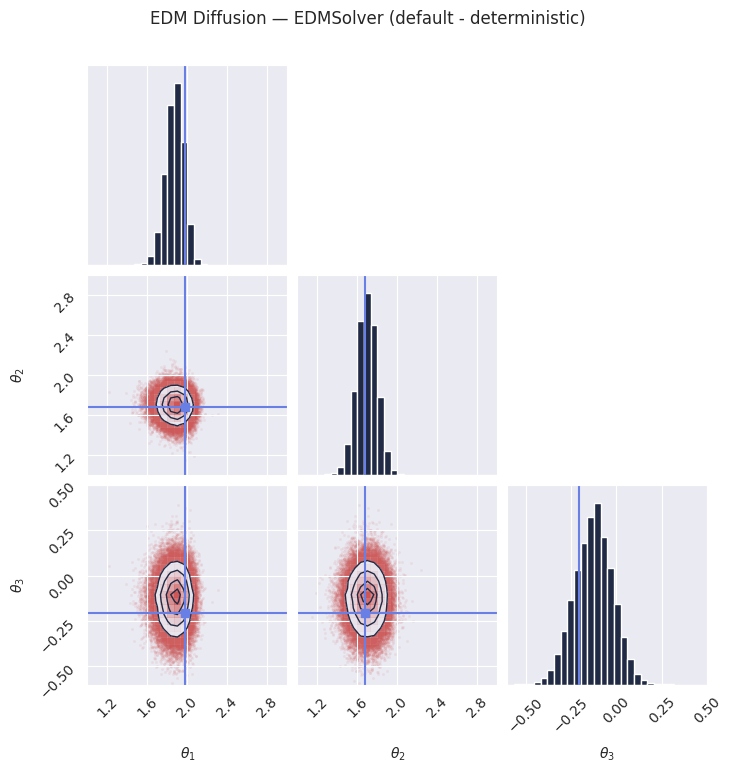

In [28]:
plot_marginals(
    np.array(samples_edm[..., 0]),
    gridsize=30,
    true_param=np.array(true_theta[0, :, 0]),
    range=plot_range,
)
plt.suptitle("EDM Diffusion — EDMSolver (default - deterministic)", y=1.02)
plt.savefig("edm_marginals.png", dpi=100, bbox_inches="tight")
plt.show()

<img src="https://raw.githubusercontent.com/aurelio-amerio/GenSBI-examples/refs/heads/main/examples/methods_and_samplers/edm_marginals.png" width=800>

In [29]:
# Setting S_churn != 0 will adopt a predictor-corrector stochastic sampling procedure, according to algorithm 2 of the paper
samples_edm_stochastic = pipeline_edm.sample(rngs.sample(), x_o, nsamples=100_000, S_churn=30)
samples_edm_stochastic = unnormalize(samples_edm_stochastic, means[:dim_obs], stds[:dim_obs])

<Figure size 640x480 with 0 Axes>

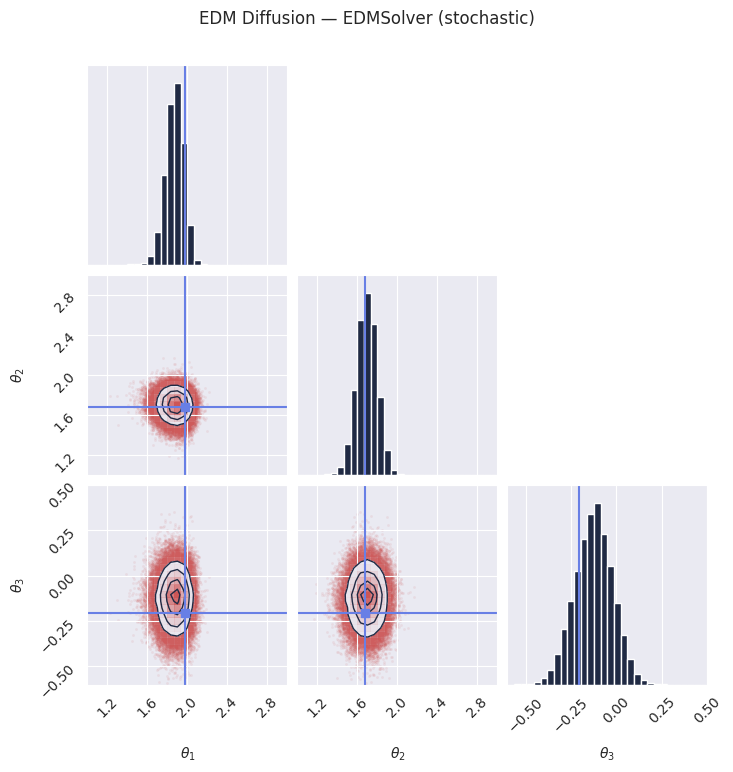

In [30]:
plot_marginals(
    np.array(samples_edm_stochastic[..., 0]),
    gridsize=30,
    true_param=np.array(true_theta[0, :, 0]),
    range=plot_range,
)
plt.suptitle("EDM Diffusion — EDMSolver (stochastic)", y=1.02)
plt.savefig("edm_marginals_stochastic.png", dpi=100, bbox_inches="tight")
plt.show()

<img src="https://raw.githubusercontent.com/aurelio-amerio/GenSBI-examples/refs/heads/main/examples/methods_and_samplers/edm_marginals_stochastic.png" width=800>

> **Note:** EDM diffusion does not currently support exact log-probability evaluation.
> Only flow matching and score matching provide this functionality via their ODE formulations.

In [31]:
del model_edm, pipeline_edm

---
## Section 3: Score Matching

**Score Matching** (Song et al., 2021) learns the score function
$\nabla \log p_t(x)$, which points toward regions of higher data density.
Samples are generated by running a **reverse-time SDE** from noise back to data.

The SDE formulation can be either:
- `ScoreMatchingMethod()` — Variance Preserving (VP) SDE (**default**)
- `ScoreMatchingMethod(sde_type="VE")` — Variance Exploding (VE) SDE

**Solvers**:
- `SMSDESolver` (**default**) — reverse-time SDE, generates stochastic samples.
- `SMODESolver` — probability flow ODE, generates deterministic samples from the
  same learned score function. Useful when reproducibility or lower variance is
  desired.

In [10]:
model_sm = Flux1(params)

# Default: Variance Preserving (VP) SDE
method_sm = ScoreMatchingMethod()
# Alternative: Variance Exploding (VE) SDE (uncomment to use)
# method_sm = ScoreMatchingMethod(sde_type="VE")

training_config_sm = ConditionalPipeline.get_default_training_config()
training_config_sm["nsteps"] = 50000
training_config_sm["checkpoint_dir"] = os.path.join(os.getcwd(), "checkpoints", "sm")

pipeline_sm = ConditionalPipeline(
    model_sm,
    train_dataset_grain,
    val_dataset_grain,
    dim_obs=dim_obs,
    dim_cond=dim_cond,
    method=method_sm,
    training_config=training_config_sm,
)

In [11]:
# Uncomment the following lines to train the model.
# Once trained, the model is saved to checkpoints/sm and can be restored below.
rngs = nnx.Rngs(42)
# pipeline_sm.train(rngs, save_model=True)

In [12]:
pipeline_sm.restore_model()

Restored model from checkpoint


In [79]:
# The default solver for score matching generates stochastic samples by running the
# reverse-time SDE. Each call with a different key produces a different set of samples.
samples_sm = pipeline_sm.sample(rngs.sample(), x_o, nsamples=100_000)
samples_sm = unnormalize(samples_sm, means[:dim_obs], stds[:dim_obs])

<Figure size 640x480 with 0 Axes>

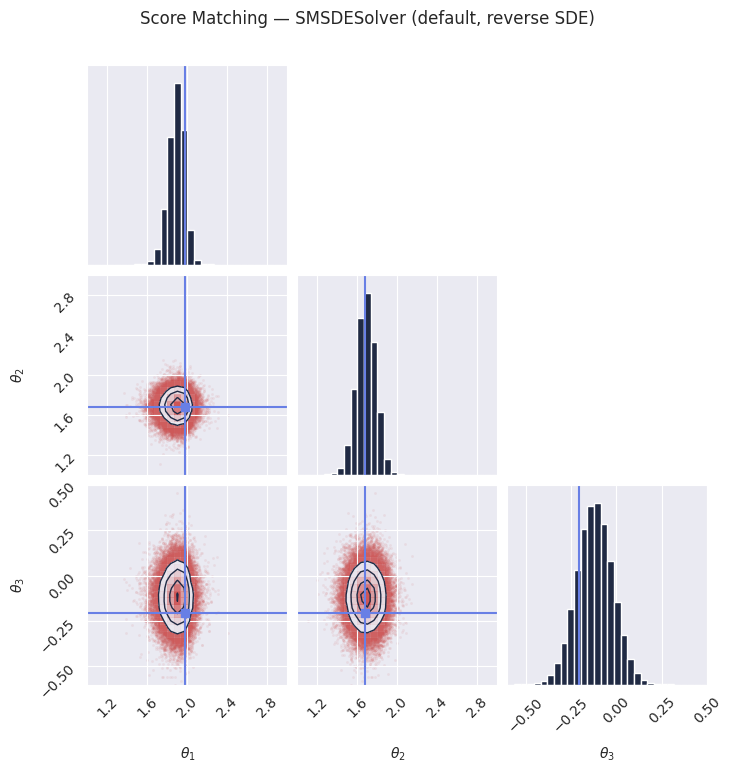

In [80]:
plot_marginals(
    np.array(samples_sm[..., 0]),
    gridsize=30,
    true_param=np.array(true_theta[0, :, 0]),
    range=plot_range,
)
plt.suptitle("Score Matching — SMSDESolver (default, reverse SDE)", y=1.02)
plt.savefig("sm_sde_marginals.png", dpi=100, bbox_inches="tight")
plt.show()

<img src="https://raw.githubusercontent.com/aurelio-amerio/GenSBI-examples/refs/heads/main/examples/methods_and_samplers/sm_sde_marginals.png" width=800>

In [81]:
# The probability flow ODE produces deterministic samples from the same learned score
# function. This can be useful when you want reproducible results or lower variance.
from gensbi.diffusion.solver import SMODESolver

samples_sm_pf = pipeline_sm.sample(
    rngs.sample(),
    x_o,
    nsamples=100_000,
    solver=(SMODESolver, {}),
)
samples_sm_pf = unnormalize(samples_sm_pf, means[:dim_obs], stds[:dim_obs])

<Figure size 640x480 with 0 Axes>

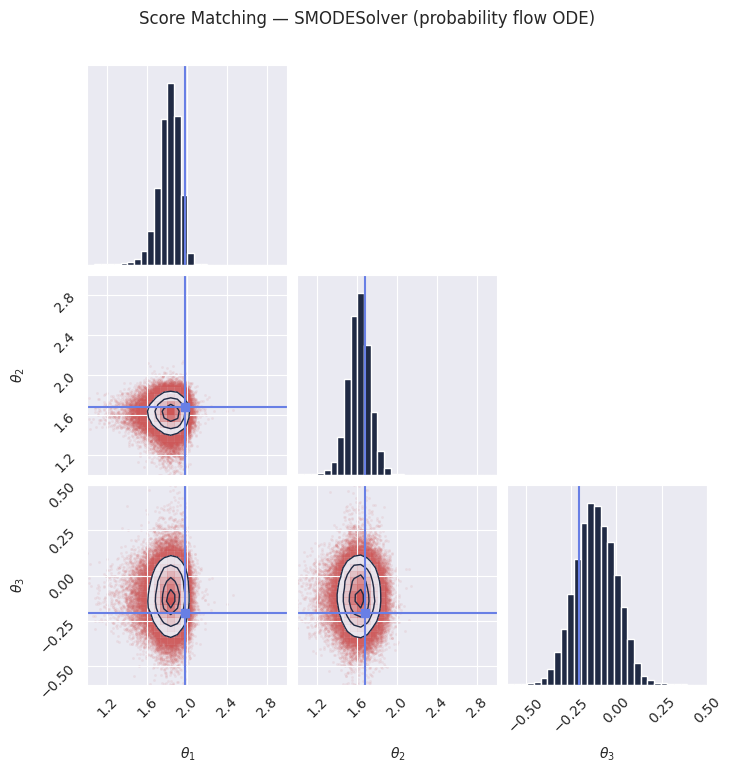

In [82]:
plot_marginals(
    np.array(samples_sm_pf[..., 0]),
    gridsize=30,
    true_param=np.array(true_theta[0, :, 0]),
    range=plot_range,
)
plt.suptitle("Score Matching — SMODESolver (probability flow ODE)", y=1.02)
plt.savefig("sm_pf_marginals.png", dpi=100, bbox_inches="tight")
plt.show()

<img src="https://raw.githubusercontent.com/aurelio-amerio/GenSBI-examples/refs/heads/main/examples/methods_and_samplers/sm_pf_marginals.png" width=800>

### Computing the log-prob (Score Matching)

Score matching also supports exact log-probability evaluation via the
probability flow ODE formulation. Internally, `pipeline.log_prob()` uses
`SMODESolver` regardless of the default sampling solver.

In [13]:
# We reuse the same unnormalized grid ranges defined in the FM section.
from gensbi.utils.plotting import _plot_2d_dist_contour

theta1_raw = np.linspace(1.6, 2.4, 20)
theta2_raw = np.linspace(1.4, 2.4, 21)
theta3_raw = np.linspace(-0.5, 0.3, 22)

means_obs = means[:dim_obs, :]
stds_obs = stds[:dim_obs, :]

theta1 = (theta1_raw - means_obs[0, 0].item()) / stds_obs[0, 0].item()
theta2 = (theta2_raw - means_obs[1, 0].item()) / stds_obs[1, 0].item()
theta3 = (theta3_raw - means_obs[2, 0].item()) / stds_obs[2, 0].item()

tt1, tt2, tt3 = jnp.meshgrid(theta1, theta2, theta3, indexing="ij")
x_1 = jnp.stack([tt1.ravel(), tt2.ravel(), tt3.ravel()], axis=-1)[..., None]

In [14]:
logp_sm = pipeline_sm.log_prob(x_1, x_o, use_ema=True, method="Euler")

E0315 23:10:35.055124   85386 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0315 23:10:35.135811   85386 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0315 23:10:35.230420   85387 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


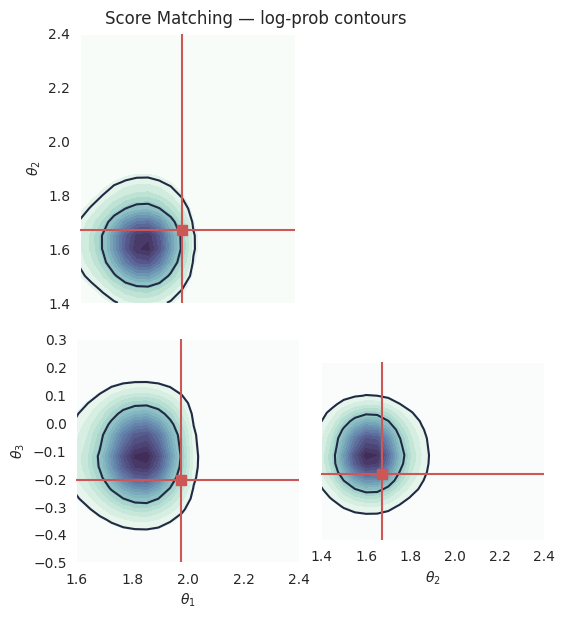

In [15]:
prob_sm = jnp.exp(logp_sm).reshape((len(theta1_raw), len(theta2_raw), len(theta3_raw)))
prob_sm = prob_sm / jnp.prod(stds_obs.flatten())

prob12_sm = jnp.trapezoid(prob_sm, x=theta3, axis=2)
prob13_sm = jnp.trapezoid(prob_sm, x=theta2, axis=1)
prob23_sm = jnp.trapezoid(prob_sm, x=theta1, axis=0)

fig, axes = plt.subplots(2, 2, figsize=(6, 6))

ax = axes[1, 0]
_plot_2d_dist_contour(theta1_raw, theta3_raw, prob13_sm.T, ax=ax,
                      true_param=[true_theta[:, 0], true_theta[:, 2]])
ax.set_xlabel(r"$\theta_1$")
ax.set_ylabel(r"$\theta_3$")

ax = axes[1, 1]
_plot_2d_dist_contour(theta2_raw, theta3_raw, prob23_sm.T, ax=ax,
                      true_param=[true_theta[:, 1], true_theta[:, 2]])
ax.set_xlabel(r"$\theta_2$")
ax.set_ylabel("")
ax.set_yticks([])

ax = axes[0, 0]
_plot_2d_dist_contour(theta1_raw, theta2_raw, prob12_sm.T, ax=ax,
                      true_param=[true_theta[:, 0], true_theta[:, 1]])
ax.set_xlabel("")
ax.set_xticks([])
ax.set_ylabel(r"$\theta_2$")

axes[0, 1].set_visible(False)

fig.subplots_adjust(hspace=0.05, wspace=0.1, left=0.2, right=0.98, top=0.98, bottom=0.06)
for ax in axes.ravel():
    ax.set_aspect("equal", adjustable="box")

plt.suptitle("Score Matching — log-prob contours", y=1.02)
plt.savefig("sm_log_prob.png", dpi=300, bbox_inches="tight")
plt.show()

In [42]:
del model_sm, pipeline_sm